Using solver: pymatsolver.Pardiso
Sheet cells: 7,500

Wrote h-field.dat


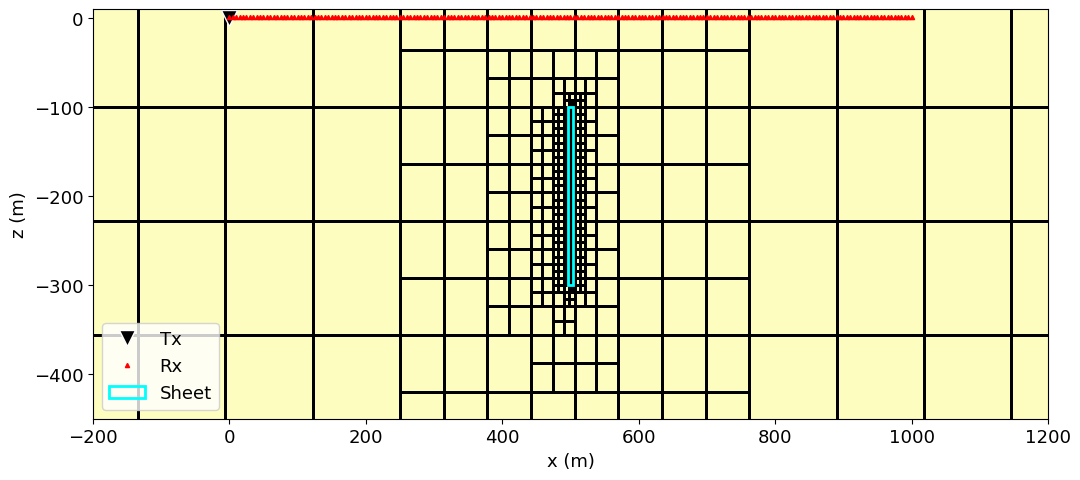

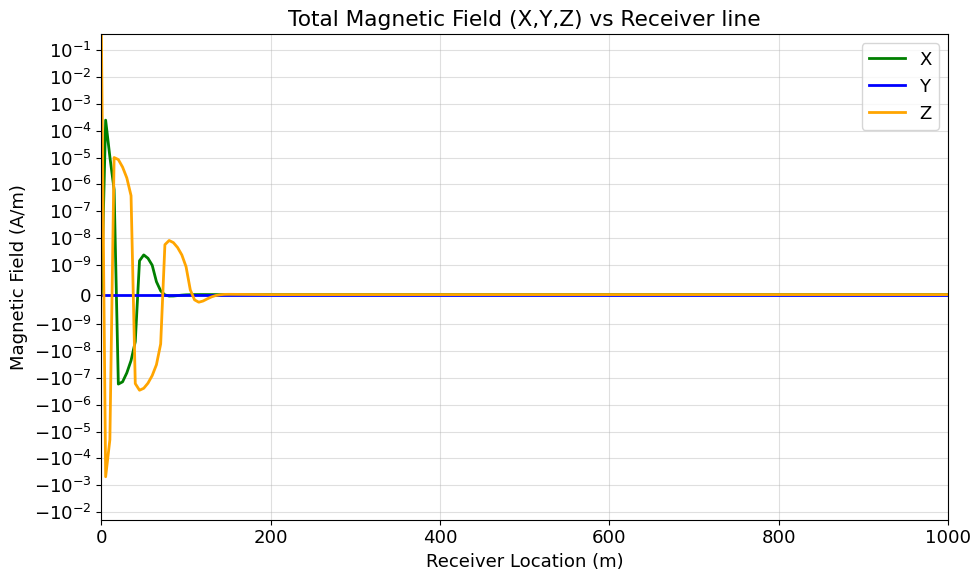

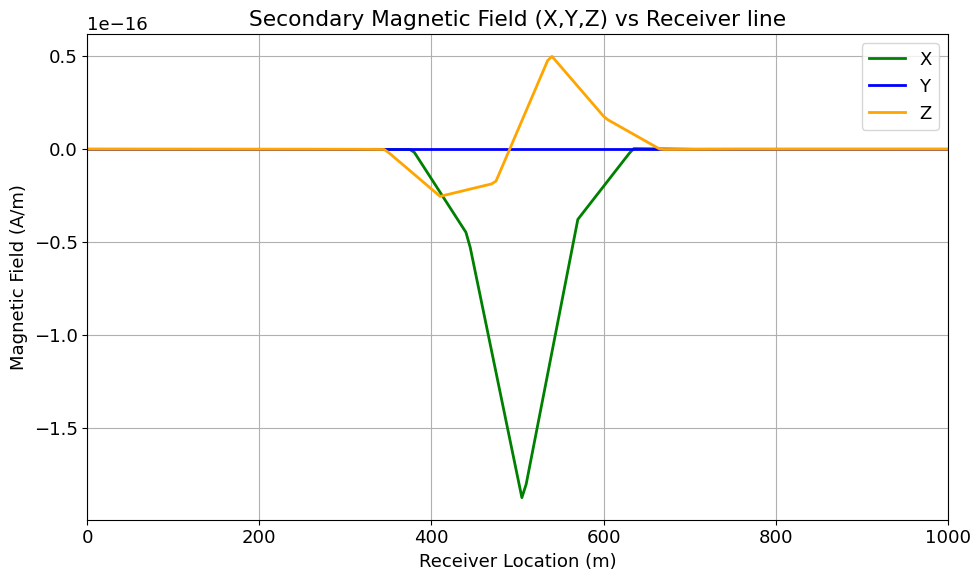

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.constants import mu_0

from discretize import TreeMesh
from SimPEG import maps
from SimPEG.electromagnetics import frequency_domain as fdem
Solver = None
solver_name = None
try:
    from pymatsolver import Pardiso as Solver
    solver_name = "pymatsolver.Pardiso"
except ImportError:
    try:
        from pymatsolver import Solver
        solver_name = "pymatsolver.Solver (SuperLU)"
    except ImportError:
        from SimPEG import SolverLU as Solver
        solver_name = "SimPEG.SolverLU (SuperLU)"
print(f"Using solver: {solver_name}")

plt.rcParams.update({"font.size": 13})
frequency = 20.0e3
src_loc   = np.array([0.0, 0.0, 0.0])
moment    = 1.0

n_rx   = 201
rx_x   = np.linspace(0.0, 1000.0, n_rx)
rx_loc = np.column_stack([rx_x, np.zeros(n_rx), np.full(n_rx, 0.75)])

rx_list = []
for orientation in ["x", "y", "z"]:
    for component in ["real", "imag"]:
        rx_list.append(
            fdem.receivers.PointMagneticFluxDensity(
                rx_loc, orientation=orientation, component=component
            )
        )

src = fdem.sources.MagDipole(
    receiver_list=rx_list,
    frequency=frequency,
    location=src_loc,
    orientation="z",
    moment=moment,
)
survey = fdem.Survey([src])
sigma_host = 1.0 / 10.0                         

true_sigma_sheet     = 1.0 / 1.0e-5              
true_sheet_thickness = 0.1                       
excess_conductance   = (true_sigma_sheet - sigma_host) * true_sheet_thickness   

sheet_thickness = 8.0
sigma_sheet     = sigma_host + excess_conductance / sheet_thickness   

sheet_cx, sheet_cy, sheet_cz = 500.0, 0.0, -200.0
sheet_strike_extent          = 200.0
sheet_dip_extent             = 200.0

sheet_xmin = sheet_cx - sheet_thickness     / 2.0
sheet_xmax = sheet_cx + sheet_thickness     / 2.0
sheet_ymin = sheet_cy - sheet_strike_extent / 2.0
sheet_ymax = sheet_cy + sheet_strike_extent / 2.0
sheet_zmin = sheet_cz - sheet_dip_extent    / 2.0
sheet_zmax = sheet_cz + sheet_dip_extent    / 2.0
dh        = 4.0
n_base    = 512
max_level = int(np.log2(n_base))

hx = [(dh, n_base)]
hy = [(dh, n_base)]
hz = [(dh, n_base)]

mesh_centre_x, mesh_centre_y, mesh_centre_z = 250.0, 0.0, -100.0
origin = [
    mesh_centre_x - n_base * dh / 2,
    mesh_centre_y - n_base * dh / 2,
    mesh_centre_z - n_base * dh / 2,
]
mesh = TreeMesh([hx, hy, hz], origin=origin)

LEVEL_BACKGROUND = max_level - 5
LEVEL_PAD        = max_level - 4
LEVEL_MID        = max_level - 3
LEVEL_NEAR       = max_level - 2
LEVEL_FINE       = max_level - 1
LEVEL_FINEST     = max_level

def box_distance(x, y, z):
    dx = max(sheet_xmin - x, 0.0, x - sheet_xmax)
    dy = max(sheet_ymin - y, 0.0, y - sheet_ymax)
    dz = max(sheet_zmin - z, 0.0, z - sheet_zmax)
    return (dx * dx + dy * dy + dz * dz) ** 0.5

def refine_func(cell):
    x, y, z = cell.center
    r_src = (x * x + y * y + z * z) ** 0.5
    if r_src <=  12.0: return LEVEL_FINEST
    if r_src <=  32.0: return LEVEL_FINE
    if r_src <=  80.0: return LEVEL_NEAR
    if abs(y) <= 16.0 and abs(z - 0.75) <= 16.0 and -20.0 <= x <= 1020.0:
        return LEVEL_FINE
    d = box_distance(x, y, z)
    if d <=  1.0 * dh: return LEVEL_FINEST
    if d <=  4.0 * dh: return LEVEL_FINE
    if d <= 10.0 * dh: return LEVEL_NEAR
    if d <= 24.0 * dh: return LEVEL_MID
    if d <= 60.0 * dh: return LEVEL_PAD
    return LEVEL_BACKGROUND

mesh.refine(refine_func, finalize=False)
mesh.finalize()
cc = mesh.cell_centers
model_bg = sigma_host * np.ones(mesh.nC)
sheet_mask = (
    (cc[:, 0] >= sheet_xmin) & (cc[:, 0] <= sheet_xmax)
    & (cc[:, 1] >= sheet_ymin) & (cc[:, 1] <= sheet_ymax)
    & (cc[:, 2] >= sheet_zmin) & (cc[:, 2] <= sheet_zmax)
)
model_tot = model_bg.copy()
model_tot[sheet_mask] = sigma_sheet
print(f"Sheet cells: {int(sheet_mask.sum()):,}")
sim = fdem.simulation.Simulation3DMagneticFluxDensity(
    mesh, survey=survey, sigmaMap=maps.IdentityMap(mesh), solver=Solver,
)
d_total = sim.dpred(model_tot)
d_primary = sim.dpred(model_bg)
def to_h_components(d):
    Hx = (d[0*n_rx:1*n_rx] + 1j*d[1*n_rx:2*n_rx]) / mu_0
    Hy = (d[2*n_rx:3*n_rx] + 1j*d[3*n_rx:4*n_rx]) / mu_0
    Hz = (d[4*n_rx:5*n_rx] + 1j*d[5*n_rx:6*n_rx]) / mu_0
    return Hx, Hy, Hz
Hx_t_sim, Hy_t_sim, Hz_t_sim = to_h_components(d_total)     
Hx_p_sim, Hy_p_sim, Hz_p_sim = to_h_components(d_primary)   

Hx_s = Hx_t_sim - Hx_p_sim
Hy_s = Hy_t_sim - Hy_p_sim
Hz_s = Hz_t_sim - Hz_p_sim

omega   = 2 * np.pi * frequency
k_host  = np.sqrt(-1j * omega * mu_0 * sigma_host)
if k_host.imag > 0:
    k_host = -k_host                                

rx_dx = rx_x - src_loc[0]
rx_dy = np.zeros(n_rx) - src_loc[1]
rx_dz = np.full(n_rx, 0.75) - src_loc[2]
rr2   = rx_dx**2 + rx_dy**2 + rx_dz**2
rr    = np.sqrt(rr2)
rr5   = rr**5

ikr     = 1j * k_host * rr
exp_ikr = np.exp(-ikr)
fac_xy  = 3.0 * (1.0 + ikr) - ikr**2

Hx_p = (moment / (4*np.pi)) * exp_ikr * rx_dx * rx_dz / rr5 * fac_xy
Hy_p = (moment / (4*np.pi)) * exp_ikr * rx_dy * rx_dz / rr5 * fac_xy
Hz_p = (moment / (4*np.pi)) * exp_ikr / rr5 * (
        (3*rx_dz**2 - rr2) * (1 + ikr) + (rr2 - rx_dz**2) * ikr**2
    )

Hz_p_freespace = (moment / (4*np.pi)) * (3*rx_dz**2 - rr2) / rr5

Hx_t = Hx_p + Hx_s
Hy_t = Hy_p + Hy_s
Hz_t = Hz_p + Hz_s

i_check = 1
i_over = 100

with open("h-field.dat", "w") as f:
    f.write(
        "    X       Y       Z    "
        "  Sec_X_Re      Sec_X_Im      Tot_X_Re      Tot_X_Im    "
        "  Sec_Y_Re      Sec_Y_Im      Tot_Y_Re      Tot_Y_Im    "
        "  Sec_Z_Re      Sec_Z_Im      Tot_Z_Re      Tot_Z_Im\n"
    )
    for i in range(n_rx):
        f.write(
            f"{rx_x[i]:8.2f} {0.0:7.2f} {0.75:7.2f} "
            f"{Hx_s[i].real:13.5e} {Hx_s[i].imag:13.5e} "
            f"{Hx_t[i].real:13.5e} {Hx_t[i].imag:13.5e} "
            f"{Hy_s[i].real:13.5e} {Hy_s[i].imag:13.5e} "
            f"{Hy_t[i].real:13.5e} {Hy_t[i].imag:13.5e} "
            f"{Hz_s[i].real:13.5e} {Hz_s[i].imag:13.5e} "
            f"{Hz_t[i].real:13.5e} {Hz_t[i].imag:13.5e}\n"
        )
print("\nWrote h-field.dat")
fig, ax = plt.subplots(figsize=(11, 5))
y_ind = int(mesh.h[1].size / 2)
mesh.plot_slice(
    np.log10(model_tot),
    normal="Y", ind=y_ind, ax=ax,
    grid=True, pcolor_opts={"cmap": "magma_r"},
)
ax.plot(src_loc[0], src_loc[2], "kv", ms=12, label="Tx", mec="white")
ax.plot(rx_loc[:, 0], rx_loc[:, 2], "r^", ms=3, label="Rx")
ax.add_patch(plt.Rectangle(
    (sheet_xmin, sheet_zmin),
    sheet_xmax - sheet_xmin, sheet_zmax - sheet_zmin,
    fill=False, edgecolor="cyan", lw=2, label="Sheet",
))
ax.set_xlim(-200, 1200); ax.set_ylim(-450, 10)
ax.set_xlabel("x (m)"); ax.set_ylabel("z (m)")
ax.set_title("")
ax.legend(loc="lower left")
plt.tight_layout()
df = pd.read_csv("h-field.dat", sep=r"\s+", skiprows=1, names=[
    'X', 'Y', 'Z',
    'Sec_X_Real', 'Sec_X_Imag', 'Tot_X_Real', 'Tot_X_Imag',
    'Sec_Y_Real', 'Sec_Y_Imag', 'Tot_Y_Real', 'Tot_Y_Imag',
    'Sec_Z_Real', 'Sec_Z_Imag', 'Tot_Z_Real', 'Tot_Z_Imag',
])
x = df['X']

TRx, TRy, TRz = df['Tot_X_Real'], df['Tot_Y_Real'], df['Tot_Z_Real']
SRx, SRy, SRz = df['Sec_X_Real'], df['Sec_Y_Real'], df['Sec_Z_Real']
fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111)
ax.plot(x, TRx, lw=2, color='green',  label='X')
ax.plot(x, TRy, lw=2, color='blue',   label='Y')
ax.plot(x, TRz, lw=2, color='orange', label='Z')
ax.set_xlim(0, 1000)
ax.set_yscale('symlog', linthresh=1e-9)
ax.set_xlabel('Receiver Location (m)')
ax.set_ylabel('Magnetic Field (A/m)')
ax.set_title('Total Magnetic Field (X,Y,Z) vs Receiver line')
ax.grid(True, which="both", alpha=0.4)
ax.legend(loc='upper right')
plt.tight_layout()
fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111)
ax.plot(x, SRx, lw=2, color='green',  label='X')
ax.plot(x, SRy, lw=2, color='blue',   label='Y')
ax.plot(x, SRz, lw=2, color='orange', label='Z')
ax.set_xlim(0, 1000)
ax.ticklabel_format(axis='y', style='sci', scilimits=(0, 0))
ax.set_xlabel('Receiver Location (m)')
ax.set_ylabel('Magnetic Field (A/m)')
ax.set_title('Secondary Magnetic Field (X,Y,Z) vs Receiver line')
ax.grid(True)
ax.legend(loc='upper right')
plt.tight_layout()

plt.show()